In [22]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from string import punctuation
from pymorphy2 import MorphAnalyzer
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from gensim.models import FastText
import numpy as np
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

negative_file='D:\\NLP\\lab1\\negative.csv'
positive_file='D:\\NLP\\lab1\\positive.csv'

negative_df = pd.read_csv(negative_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])
positive_df = pd.read_csv(positive_file, delimiter=";",header=None, names=["id", "tdate", "tmane",'ttext', 'ttype', 'trep', 'trtv','tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])

df = pd.concat([negative_df, positive_df]).reset_index(drop=True)
df = df[['ttext', 'ttype']]
df['ttype'] = df['ttype'].apply(lambda x: 0 if x < 0 else 1)
df.head()

,ttext,ttype
0,на работе был полный пиддес :| и так каждое за...,0
1,"Коллеги сидят рубятся в Urban terror, а я из-з...",0
2,@elina_4post как говорят обещаного три года жд...,0
3,"Желаю хорошего полёта и удачной посадки,я буду...",0
4,"Обновил за каким-то лешим surf, теперь не рабо...",0


In [4]:
nltk.download("stopwords")
nltk.download('punkt_tab')
stop_words = stopwords.words("russian")
remove_tokens = ['не', 'нельзя', 'лучше', 'хорошо', 'никогда', 'зачем', 'нет', 'да', '00', '10', '100', '11', '12', '13', '14', '15', '16', '17', '18', '20', '2013', '2014', '21', '25', '30', '33', '40', '50', '99', 'http', 'https', 'follow', 'amp', 'cio_optimal', 'co', 'dd', 'ddd', 'gt', 'rt', 'the', 'lt', 'mtvstars', 'teamfollowback', 'tukvasociopat']
stop_words.extend(remove_tokens)

punctuations = list(punctuation)
punkt = ['``','...',"''",'«','»','…','”','”','“','-','–','..',':','|','@','—']
punctuations.extend(punkt)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lezchook\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lezchook\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [5]:
tqdm.pandas()
morph = MorphAnalyzer()

def text_preprocessing(text):
    tokens = nltk.word_tokenize(text, language="russian")
    tokens = [word for word in tokens if word.lower() not in stop_words and word not in punctuations]
    lemmas = [morph.parse(token)[0].normal_form for token in tokens]
    return lemmas

df['ttext'] = df['ttext'].progress_apply(text_preprocessing)
df.head()

  0%|          | 0/226834 [00:00<?, ?it/s]

,ttext,ttype
0,"[работа, полный, пиддес, каждый, закрытие, мес...",0
1,"[коллега, сидеть, рубиться, urban, terror, из-...",0
2,"[elina_4post, говорить, обещаной, год, ждать]",0
3,"[желать, хороший, полёт, удачный, посадка, быт...",0
4,"[обновить, какой-то, леший, surf, работать, пр...",0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(df["ttext"], df["ttype"], test_size=0.2, random_state=42)
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

In [7]:
w2v_model = Word2Vec(sentences=X_train["ttext"], vector_size=300, window=5, min_count=1, workers=8)

In [8]:
def preprocess_word2vec(tokens):
    result = []
    for token in tokens:
        try:
            result.append(w2v_model.wv[token])
        except KeyError:
            result.append(np.zeros(w2v_model.vector_size))
            
    if result:
        return np.array(result).mean(axis=0)
    else:
        return np.zeros(w2v_model.vector_size)

X_train_word2vec = pd.DataFrame(X_train["ttext"].progress_apply(preprocess_word2vec).to_list(), columns=np.arange(1, 301))
X_test_word2vec = pd.DataFrame(X_test["ttext"].progress_apply(preprocess_word2vec).to_list(), columns=np.arange(1, 301))
X_train_word2vec.head()

  0%|          | 0/181467 [00:00<?, ?it/s]

  0%|          | 0/45367 [00:00<?, ?it/s]

,1,2,3,4,5,6,7,8,9,10,...,291,292,293,294,295,296,297,298,299,300
0,-0.023680,0.398790,-0.112507,0.310080,0.075174,-0.485188,0.206999,1.042364,0.122772,-0.136145,...,0.105554,0.400924,0.326696,0.278632,0.392862,0.613144,-0.077992,-0.250662,0.394439,-0.114054
1,0.117471,0.642343,0.017342,0.029188,0.123954,-0.421111,0.457906,1.168245,0.273685,-0.061491,...,0.065166,0.596207,0.563335,0.179439,0.423142,0.622710,0.037426,-0.088160,0.440444,-0.381019
2,-0.029879,0.426061,-0.045166,0.149145,0.080844,-0.617702,0.431449,1.176299,-0.015806,-0.215218,...,0.193638,0.631280,0.443653,-0.108763,0.616068,0.543869,0.124144,-0.123607,0.502408,-0.451673
3,0.000474,0.005728,0.000708,0.004079,0.002038,-0.003831,0.004196,0.012838,0.001383,-0.003235,...,0.000667,0.007633,0.005346,0.001242,0.001260,0.007265,0.000866,0.000584,0.003378,-0.000212
4,-0.030114,0.545552,0.032053,0.272557,0.248969,-0.601854,0.354201,1.411069,0.149837,0.005667,...,0.262348,0.655178,0.443751,0.180631,0.496799,0.725985,-0.026901,-0.303014,0.660645,-0.099894


In [9]:
fastText_model = FastText(sentences=X_train["ttext"], vector_size=300, window=5, min_count=1, workers=8)

In [10]:
def preprocess_fastText(tokens):
    result = []
    for token in tokens:
        try:
            result.append(fastText_model.wv[token])
        except KeyError:
            result.append(np.zeros(fastText_model.vector_size))
            
    if result:
        return np.array(result).mean(axis=0)
    else:
        return np.zeros(fastText_model.vector_size)


X_train_fastText = pd.DataFrame(X_train["ttext"].apply(preprocess_fastText).to_list(), columns=np.arange(1, 301))
X_test_fastText = pd.DataFrame(X_test["ttext"].apply(preprocess_fastText).to_list(), columns=np.arange(1, 301))
X_train_fastText.head()

,1,2,3,4,5,6,7,8,9,10,...,291,292,293,294,295,296,297,298,299,300
0,0.229009,0.180487,-0.608099,-0.348969,-0.218424,-0.211323,0.293346,-0.290180,-0.084418,-0.237484,...,0.171089,0.321123,-0.971430,0.245099,-0.102197,-0.197460,0.268559,0.251434,1.063324,0.502449
1,0.136268,0.748197,-0.255780,-0.555172,0.327400,0.005571,0.935512,-0.026796,-0.128272,-0.171409,...,0.673803,0.637706,-1.528078,-0.040419,0.000649,-1.059370,0.470959,-0.074689,2.585999,1.150022
2,-0.049559,0.562332,-0.757008,-0.336496,-0.076470,0.075602,0.300722,-0.191705,-0.447251,-0.347001,...,0.275294,0.567919,-1.156091,-0.025736,-0.124972,-0.409106,0.311736,0.004651,1.181034,0.927643
3,0.123129,0.181741,-0.212664,-0.248184,-0.013336,-0.054811,0.443839,-0.110391,-0.204567,0.040677,...,0.074219,0.191179,-0.829666,-0.129259,0.004323,-0.458251,0.135261,0.117825,1.147019,0.485057
4,0.198595,0.342894,-0.620167,-0.235340,-0.124788,-0.232211,-0.048622,0.167083,0.086862,-0.505150,...,0.358501,-0.094288,-1.135835,-0.162069,0.089279,-0.245635,0.407613,0.522615,0.798319,0.332043


In [11]:
word2idx = {"<PAD>": 0, "<UNK>": 1}

for tokens in X_train["ttext"]:
    for token in tokens:
        if token not in word2idx:
            word2idx[token] = len(word2idx)

vocab_size = len(word2idx)

In [ ]:
def preprocess_embedding(tokens):
    return [word2idx.get(token, word2idx["<UNK>"]) for token in tokens]

X_train_embedding = [preprocess_embedding(tokens) for tokens in X_train["ttext"]]
X_test_embedding = [preprocess_embedding(tokens) for tokens in X_test["ttext"]]

max_len = max(len(embedding) for embedding in X_train_embedding)
X_train_embedding = [embedding + [word2idx["<PAD>"]] * (max_len - len(embedding)) for embedding in X_train_embedding]
X_test_embedding = [embedding + [word2idx["<PAD>"]] * (max_len - len(embedding)) for embedding in X_test_embedding]

In [13]:
class CustomDataset(Dataset):
    def __init__(self, inputs, targets, device):
        self.inputs = torch.tensor(inputs, dtype=torch.float32).to(device)
        self.targets = torch.tensor(targets, dtype=torch.int64).to(device)

    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

class NeuralModel_1(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.layer1 = nn.Linear(input_shape, 32)
        self.layer2 = nn.Linear(32, 2)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = self.layer2(x)
        return F.log_softmax(x, dim=1)

class NeuralModel_2(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.layer1 = nn.Linear(input_shape, 32)
        self.layer2 = nn.Linear(32, 32)
        self.layer3 = nn.Linear(32, 2)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x)
        return F.log_softmax(x, dim=1)

class NeuralModel_3(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.layer1 = nn.Linear(input_shape, 32)
        self.layer2 = nn.Linear(32, 32)
        self.layer3 = nn.Linear(32, 32)
        self.layer4 = nn.Linear(32, 2)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        x = self.layer4(x)
        return F.log_softmax(x, dim=1)

class NeuralModel_4(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.layer1 = nn.Linear(input_shape, 32)
        self.layer2 = nn.Linear(32, 64)
        self.layer3 = nn.Linear(64, 32)
        self.layer4 = nn.Linear(32, 2)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        x = self.layer4(x)
        return F.log_softmax(x, dim=1)

class NeuralModel_5(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.layer1 = nn.Linear(input_shape, 32)
        self.layer2 = nn.Linear(32, 64)
        self.layer3 = nn.Linear(64, 64)
        self.layer4 = nn.Linear(64, 2)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        x = self.layer4(x)
        return F.log_softmax(x, dim=1)

## Word2Vec

In [14]:
models = [
    NeuralModel_1(input_shape=X_train_word2vec.shape[1]).to(device),
    NeuralModel_2(input_shape=X_train_word2vec.shape[1]).to(device),
    NeuralModel_3(input_shape=X_train_word2vec.shape[1]).to(device),
    NeuralModel_4(input_shape=X_train_word2vec.shape[1]).to(device),
    NeuralModel_5(input_shape=X_train_word2vec.shape[1]).to(device)
]
model_labels = ["Model_1", "Model_2", "Model_3", "Model_4", "Model_5"]

optimizer_lrs = [0.01, 0.001, 0.0001]

for model_idx, model in enumerate(models):
    for optimizer_lr_idx, optimizer_lr in enumerate(optimizer_lrs):
        optimizer = optim.AdamW(model.parameters(), lr=optimizer_lr)
        loss_function = nn.CrossEntropyLoss()

        trainloader = torch.utils.data.DataLoader(CustomDataset(X_train_word2vec.to_numpy(), y_train.to_numpy(), device), batch_size=128, shuffle=True)
        testloader = torch.utils.data.DataLoader(CustomDataset(X_test_word2vec.to_numpy(), y_test.to_numpy(), device), batch_size=128, shuffle=False)

        for epoch in range(10):
            model.train()
            for data in trainloader:
                X, y = data
                output = model(X)
                loss = loss_function(output, y)

                model.zero_grad()
                loss.backward()
                optimizer.step()

        model.eval()
        y_pred = []
        with torch.no_grad():
            for data in testloader:
                X, y = data
                output = model(X)
                predictions = torch.argmax(output, dim=1).cpu().numpy()
                y_pred.extend(predictions)

        print(model_labels[model_idx], optimizer_lrs[optimizer_lr_idx])
        print(classification_report(y_test, y_pred))
        print()

Model_1 0.01
              precision    recall  f1-score   support

           0       0.73      0.55      0.63     22298
           1       0.65      0.81      0.72     23069

    accuracy                           0.68     45367
   macro avg       0.69      0.68      0.67     45367
weighted avg       0.69      0.68      0.67     45367


Model_1 0.001
              precision    recall  f1-score   support

           0       0.69      0.68      0.69     22298
           1       0.70      0.71      0.70     23069

    accuracy                           0.69     45367
   macro avg       0.69      0.69      0.69     45367
weighted avg       0.69      0.69      0.69     45367


Model_1 0.0001
              precision    recall  f1-score   support

           0       0.69      0.70      0.69     22298
           1       0.70      0.69      0.70     23069

    accuracy                           0.70     45367
   macro avg       0.70      0.70      0.70     45367
weighted avg       0.70      0

## FastText

In [15]:
models = [
    NeuralModel_1(input_shape=X_train_fastText.shape[1]).to(device),
    NeuralModel_2(input_shape=X_train_fastText.shape[1]).to(device),
    NeuralModel_3(input_shape=X_train_fastText.shape[1]).to(device),
    NeuralModel_4(input_shape=X_train_fastText.shape[1]).to(device),
    NeuralModel_5(input_shape=X_train_fastText.shape[1]).to(device)
]
model_labels = ["Model_1", "Model_2", "Model_3", "Model_4", "Model_5"]

optimizer_lrs = [0.01, 0.001, 0.0001]

for model_idx, model in enumerate(models):
    for optimizer_lr_idx, optimizer_lr in enumerate(optimizer_lrs):
        optimizer = optim.AdamW(model.parameters(), lr=optimizer_lr)
        loss_function = nn.CrossEntropyLoss()

        trainloader = torch.utils.data.DataLoader(CustomDataset(X_train_fastText.to_numpy(), y_train.to_numpy(), device), batch_size=128, shuffle=True)
        testloader = torch.utils.data.DataLoader(CustomDataset(X_test_fastText.to_numpy(), y_test.to_numpy(), device), batch_size=128, shuffle=False)

        for epoch in range(10):
            model.train()
            for data in trainloader:
                X, y = data
                output = model(X)
                loss = loss_function(output, y)

                model.zero_grad()
                loss.backward()
                optimizer.step()

        model.eval()
        y_pred = []
        with torch.no_grad():
            for data in testloader:
                X, y = data
                output = model(X)
                predictions = torch.argmax(output, dim=1).cpu().numpy()
                y_pred.extend(predictions)

        print(model_labels[model_idx], optimizer_lrs[optimizer_lr_idx])
        print(classification_report(y_test, y_pred))
        print()

Model_1 0.01
              precision    recall  f1-score   support

           0       0.67      0.69      0.68     22298
           1       0.69      0.67      0.68     23069

    accuracy                           0.68     45367
   macro avg       0.68      0.68      0.68     45367
weighted avg       0.68      0.68      0.68     45367


Model_1 0.001
              precision    recall  f1-score   support

           0       0.69      0.67      0.68     22298
           1       0.69      0.71      0.70     23069

    accuracy                           0.69     45367
   macro avg       0.69      0.69      0.69     45367
weighted avg       0.69      0.69      0.69     45367


Model_1 0.0001
              precision    recall  f1-score   support

           0       0.69      0.67      0.68     22298
           1       0.69      0.71      0.70     23069

    accuracy                           0.69     45367
   macro avg       0.69      0.69      0.69     45367
weighted avg       0.69      0

## torch.nn.Embedding

In [16]:
class CustomDataset(Dataset):
    def __init__(self, inputs, targets, device):
        self.inputs = torch.tensor(inputs, dtype=torch.int64).to(device)
        self.targets = torch.tensor(targets, dtype=torch.int64).to(device)

    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

class NeuralModel_1(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.layer1 = nn.Linear(embedding_dim, 32)
        self.layer2 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.embedding(x)
        x = x.mean(dim=1)
        x = F.relu(self.layer1(x))
        x = self.layer2(x)
        return F.log_softmax(x, dim=1)

class NeuralModel_2(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.layer1 = nn.Linear(embedding_dim, 32)
        self.layer2 = nn.Linear(32, 32)
        self.layer3 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.embedding(x)
        x = x.mean(dim=1)
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x)
        return F.log_softmax(x, dim=1)

class NeuralModel_3(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.layer1 = nn.Linear(embedding_dim, 32)
        self.layer2 = nn.Linear(32, 32)
        self.layer3 = nn.Linear(32, 32)
        self.layer4 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.embedding(x)
        x = x.mean(dim=1)
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        x = self.layer4(x)
        return F.log_softmax(x, dim=1)

class NeuralModel_4(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.layer1 = nn.Linear(embedding_dim, 32)
        self.layer2 = nn.Linear(32, 64)
        self.layer3 = nn.Linear(64, 32)
        self.layer4 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.embedding(x)
        x = x.mean(dim=1)
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        x = self.layer4(x)
        return F.log_softmax(x, dim=1)

class NeuralModel_5(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.layer1 = nn.Linear(embedding_dim, 32)
        self.layer2 = nn.Linear(32, 64)
        self.layer3 = nn.Linear(64, 64)
        self.layer4 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.embedding(x)
        x = x.mean(dim=1)
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        x = self.layer4(x)
        return F.log_softmax(x, dim=1)

In [ ]:

models = [
    NeuralModel_1(vocab_size=vocab_size, embedding_dim=300).to(device),
    NeuralModel_2(vocab_size=vocab_size, embedding_dim=300).to(device),
    NeuralModel_3(vocab_size=vocab_size, embedding_dim=300).to(device),
    NeuralModel_4(vocab_size=vocab_size, embedding_dim=300).to(device),
    NeuralModel_5(vocab_size=vocab_size, embedding_dim=300).to(device),
]
model_labels = ["Model_1", "Model_2", "Model_3", "Model_4", "Model_5"]

optimizer_lrs = [0.01, 0.001, 0.0001]

for model_idx, model in enumerate(models):
    for optimizer_lr_idx, optimizer_lr in enumerate(optimizer_lrs):
        optimizer = optim.AdamW(model.parameters(), lr=optimizer_lr)
        loss_function = nn.CrossEntropyLoss()

        trainloader = torch.utils.data.DataLoader(CustomDataset(X_train_embedding, y_train.to_numpy(), device), batch_size=128, shuffle=True)
        testloader = torch.utils.data.DataLoader(CustomDataset(X_test_embedding, y_test.to_numpy(), device), batch_size=128, shuffle=False)

        for epoch in range(10):
            model.train()
            for data in trainloader:
                X, y = data
                output = model(X)
                loss = loss_function(output, y)

                model.zero_grad()
                loss.backward()
                optimizer.step()

        model.eval()
        y_pred = []
        with torch.no_grad():
            for data in testloader:
                X, y = data
                output = model(X)
                predictions = torch.argmax(output, dim=1).cpu().numpy()
                y_pred.extend(predictions)

        print(model_labels[model_idx], optimizer_lrs[optimizer_lr_idx])
        print(classification_report(y_test, y_pred))
        print()

Model_1 0.01
              precision    recall  f1-score   support

           0       0.71      0.85      0.77     22298
           1       0.82      0.66      0.73     23069

    accuracy                           0.75     45367
   macro avg       0.76      0.76      0.75     45367
weighted avg       0.77      0.75      0.75     45367


Model_1 0.001
              precision    recall  f1-score   support

           0       0.73      0.81      0.77     22298
           1       0.80      0.72      0.75     23069

    accuracy                           0.76     45367
   macro avg       0.77      0.76      0.76     45367
weighted avg       0.77      0.76      0.76     45367


Model_1 0.0001
              precision    recall  f1-score   support

           0       0.74      0.80      0.77     22298
           1       0.79      0.74      0.76     23069

    accuracy                           0.77     45367
   macro avg       0.77      0.77      0.77     45367
weighted avg       0.77      0

## Вывод по работе

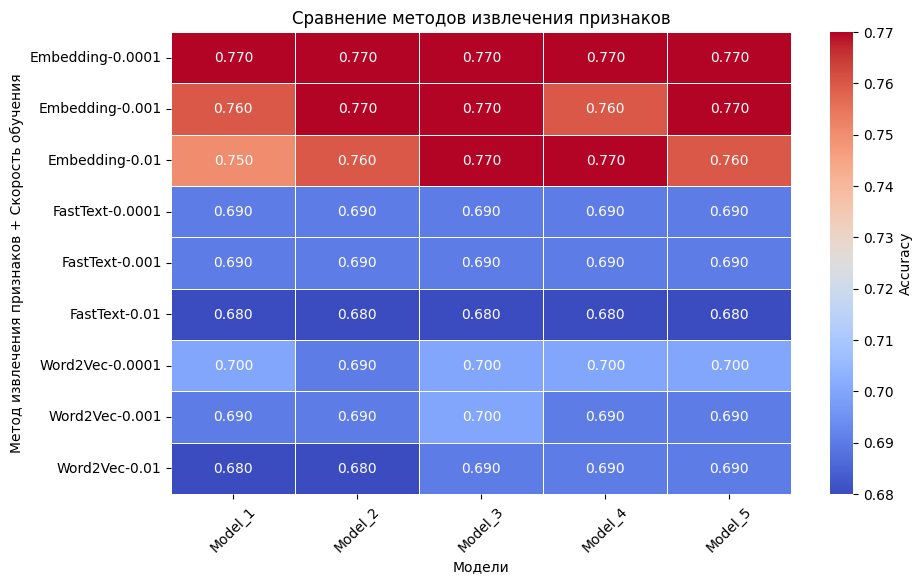

In [23]:
feature_extraction_methods = ["Word2Vec", "FastText", "Embedding"]
model_labels = ["Model_1", "Model_2", "Model_3", "Model_4", "Model_5"]
optimizer_lrs = [0.01, 0.001, 0.0001]

data = [
    [
        'Word2Vec',
        0.01,
        0.68,
        0.68,
        0.69,
        0.69,
        0.69
    ],
    [
        'Word2Vec',
        0.001,
        0.69,
        0.69,
        0.70,
        0.69,
        0.69
    ],
    [
        'Word2Vec',
        0.0001,
        0.70,
        0.69,
        0.70,
        0.70,
        0.70
    ],
    [
        'FastText',
        0.01,
        0.68,
        0.68,
        0.68,
        0.68,
        0.68
    ],
    [
        'FastText',
        0.001,
        0.69,
        0.69,
        0.69,
        0.69,
        0.69
    ],
    [
        'FastText',
        0.0001,
        0.69,
        0.69,
        0.69,
        0.69,
        0.69
    ],
    [
        'Embedding',
        0.01,
        0.75,
        0.76,
        0.77,
        0.77,
        0.76
    ],
    [
        'Embedding',
        0.001,
        0.76,
        0.77,
        0.77,
        0.76,
        0.77
    ],
    [
        'Embedding',
        0.0001,
        0.77,
        0.77,
        0.77,
        0.77,
        0.77
    ]
]

columns = ["Feature Extraction", "Learning Rate"] + model_labels
df = pd.DataFrame(data, columns=columns)

df_melted = df.melt(id_vars=["Feature Extraction", "Learning Rate"],
                     var_name="Model", value_name="Accuracy")

df_pivot = df_melted.pivot_table(index=["Feature Extraction", "Learning Rate"],
                                 columns="Model", values="Accuracy")

plt.figure(figsize=(10, 6))
sns.heatmap(df_pivot, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5, cbar_kws={'label': 'Accuracy'})
plt.title("Сравнение методов извлечения признаков")
plt.xlabel("Модели")
plt.ylabel("Метод извлечения признаков + Скорость обучения")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

Таким образом можно сделать вывод о том, что самый наилучший результат по метрике accuracy получается при использовании embedding, а низикая скорость обучения позволяет достичь лучшей точности, усложнение архитектуры нейронной сети особо не влияло на результат в данном случае